<a href="https://colab.research.google.com/github/Bowiya16/Driver-drowsiness-detection-system-using-eye-closer-and-yawning-analysis-with-deep-learning/blob/main/Driver.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

DRIVER DROWSINESS DETECTION

In [ ]:
#IMPORT LIBRARIES
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Dense, Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dropout, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.applications import MobileNetV2

from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

import tensorflow as tf

In [ ]:
#UPLOAD DATASET ZIP
from google.colab import files
uploaded = files.upload()

Saving archive (2).zip to archive (2).zip


In [ ]:
#UNZIP DATASET
import zipfile

with zipfile.ZipFile('/content/archive (2).zip', 'r') as zip_ref:
    zip_ref.extractall('/content/data')

print("Dataset Extracted Successfully")

Dataset Extracted Successfully


In [ ]:
#CHECK DATASET STRUCTURE
import os

print(os.listdir('/content/data'))

['train']


In [ ]:
dataset_path = '/content/data/train'

In [ ]:
#CLASS NAMES
import os

print(os.listdir('/content/data/train'))

['Closed', 'Open', 'no_yawn', 'yawn']


In [ ]:
#DATA PREPROCESSING
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Dataset Path
dataset_path = '/content/data/train'

# Image Size
IMG_SIZE = (224,224)

# Batch Size
BATCH_SIZE = 32

# Data Augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=20,
    zoom_range=0.2,
    brightness_range=[0.8,1.2],
    horizontal_flip=True
)

# Training Generator
train_generator = train_datagen.flow_from_directory(
    dataset_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training'
)

# Validation Generator
val_generator = train_datagen.flow_from_directory(
    dataset_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation'
)

Found 2321 images belonging to 4 classes.
Found 579 images belonging to 4 classes.


In [ ]:
import os

print(os.listdir('/content'))

['.config', 'sample_data']


In [ ]:
#CLASS NAMES
class_names = list(train_generator.class_indices.keys())

print(class_names)

['Closed', 'Open', 'no_yawn', 'yawn']


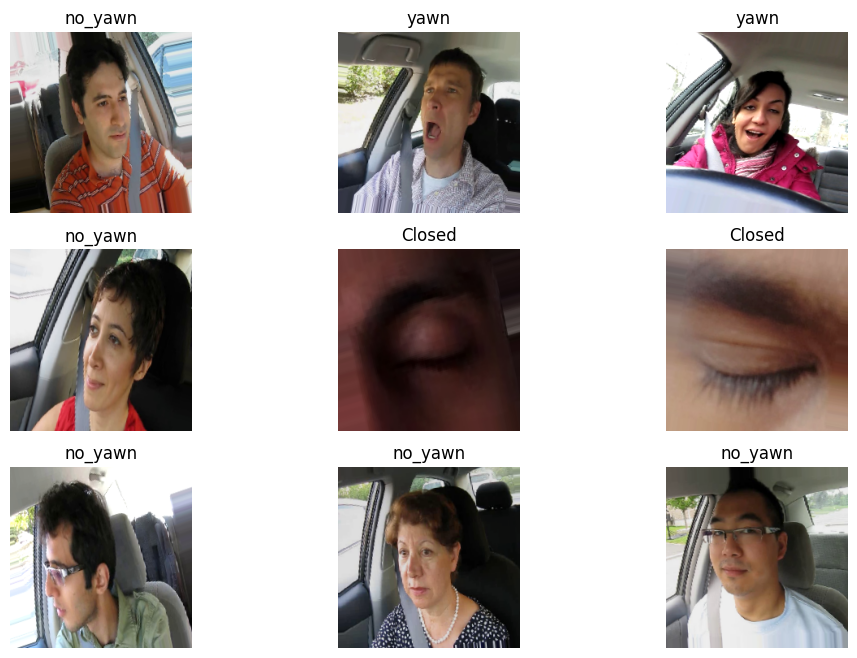

In [ ]:
#VISUALIZE IMAGES
images, labels = next(train_generator)

plt.figure(figsize=(12,8))

for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(images[i])
    plt.title(class_names[np.argmax(labels[i])])
    plt.axis('off')

plt.show()

In [ ]:
#CUSTOM CNN MODEL
cnn_model = Sequential([

    Conv2D(32,(3,3),activation='relu',input_shape=(224,224,3)),
    MaxPooling2D(2,2),

    Conv2D(64,(3,3),activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128,(3,3),activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),

    Dense(128,activation='relu'),
    Dropout(0.5),

    Dense(4,activation='softmax')
])

cnn_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

cnn_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,476 (42.61 MB)

 Trainable params: 11,169,476 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
#TRAIN CNN MODEL
cnn_history = cnn_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10
)

Epoch 1/10
73/73 ━━━━━━━━━━━━━━━━━━━━ 58s 679ms/step - accuracy: 0.6161 - loss: 0.7709 - val_accuracy: 0.6753 - val_loss: 0.5318
Epoch 2/10
73/73 ━━━━━━━━━━━━━━━━━━━━ 46s 628ms/step - accuracy: 0.7570 - loss: 0.4670 - val_accuracy: 0.6269 - val_loss: 0.5481
Epoch 3/10
73/73 ━━━━━━━━━━━━━━━━━━━━ 43s 594ms/step - accuracy: 0.7854 - loss: 0.4159 - val_accuracy: 0.6701 - val_loss: 0.5373
Epoch 4/10
73/73 ━━━━━━━━━━━━━━━━━━━━ 45s 615ms/step - accuracy: 0.7945 - loss: 0.3889 - val_accuracy: 0.7444 - val_loss: 0.5917
Epoch 5/10
73/73 ━━━━━━━━━━━━━━━━━━━━ 42s 575ms/step - accuracy: 0.8014 - loss: 0.3877 - val_accuracy: 0.7686 - val_loss: 0.4881
Epoch 6/10
73/73 ━━━━━━━━━━━━━━━━━━━━ 43s 593ms/step - accuracy: 0.8087 - loss: 0.3588 - val_accuracy: 0.6701 - val_loss: 0.5811
Epoch 7/10
73/73 ━━━━━━━━━━━━━━━━━━━━ 42s 581ms/step - accuracy: 0.8091 - loss: 0.3652 - val_accuracy: 0.6511 - val_loss: 0.5900
Epoch 8/10
73/73 ━━━━━━━━━━━━━━━━━━━━ 43s 586ms/step - accuracy: 0.8238 - loss: 0.3366 - val_accu

In [ ]:
from tensorflow.keras.applications import MobileNetV2

In [ ]:
from tensorflow.keras.models import Model

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from tensorflow.keras.models import Sequential, Model

from tensorflow.keras.layers import (
    Dense,
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dropout,
    GlobalAveragePooling2D
)

from tensorflow.keras.optimizers import Adam

from tensorflow.keras.applications import MobileNetV2

In [ ]:
# MobileNetV2 Model

base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

base_model.trainable = False

x = base_model.output

x = GlobalAveragePooling2D()(x)

x = Dense(128, activation='relu')(x)

x = Dropout(0.5)(x)

predictions = Dense(4, activation='softmax')(x)

mobilenet_model = Model(
    inputs=base_model.input,
    outputs=predictions
)

mobilenet_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

mobilenet_model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,422,468 (9.24 MB)

 Trainable params: 164,484 (642.52 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
#train mob net model
mobilenet_history = mobilenet_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10
)

Epoch 1/10
73/73 ━━━━━━━━━━━━━━━━━━━━ 70s 830ms/step - accuracy: 0.7617 - loss: 0.4753 - val_accuracy: 0.7237 - val_loss: 0.3761
Epoch 2/10
73/73 ━━━━━━━━━━━━━━━━━━━━ 42s 579ms/step - accuracy: 0.8225 - loss: 0.3306 - val_accuracy: 0.7202 - val_loss: 0.3902
Epoch 3/10
73/73 ━━━━━━━━━━━━━━━━━━━━ 44s 601ms/step - accuracy: 0.8354 - loss: 0.3051 - val_accuracy: 0.7582 - val_loss: 0.3886
Epoch 4/10
73/73 ━━━━━━━━━━━━━━━━━━━━ 41s 559ms/step - accuracy: 0.8518 - loss: 0.2773 - val_accuracy: 0.7306 - val_loss: 0.3965
Epoch 5/10
73/73 ━━━━━━━━━━━━━━━━━━━━ 42s 570ms/step - accuracy: 0.8746 - loss: 0.2515 - val_accuracy: 0.7444 - val_loss: 0.3944
Epoch 6/10
73/73 ━━━━━━━━━━━━━━━━━━━━ 41s 563ms/step - accuracy: 0.8763 - loss: 0.2517 - val_accuracy: 0.7478 - val_loss: 0.4170
Epoch 7/10
73/73 ━━━━━━━━━━━━━━━━━━━━ 41s 565ms/step - accuracy: 0.8858 - loss: 0.2418 - val_accuracy: 0.7599 - val_loss: 0.4076
Epoch 8/10
73/73 ━━━━━━━━━━━━━━━━━━━━ 42s 584ms/step - accuracy: 0.8897 - loss: 0.2354 - val_accu

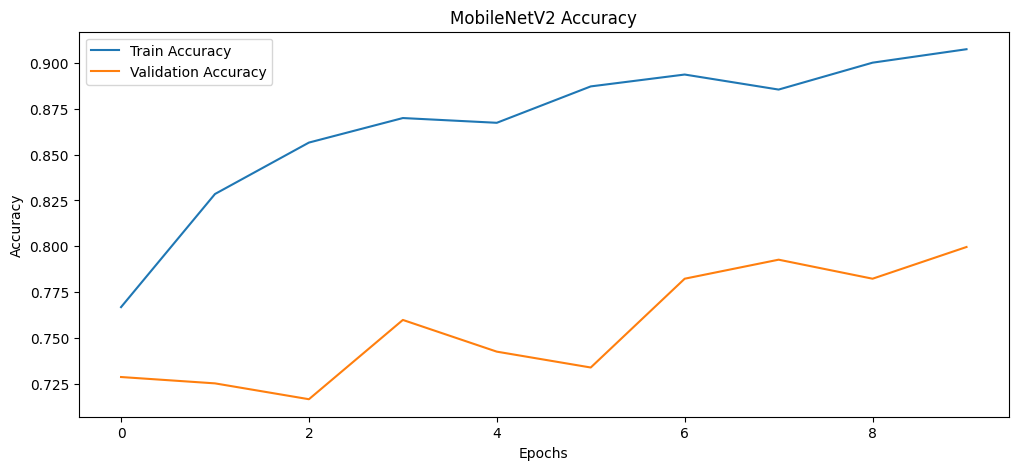

In [ ]:
#accuracy graph
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.plot(mobilenet_history.history['accuracy'], label='Train Accuracy')
plt.plot(mobilenet_history.history['val_accuracy'], label='Validation Accuracy')

plt.title('MobileNetV2 Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')

plt.legend()
plt.show()

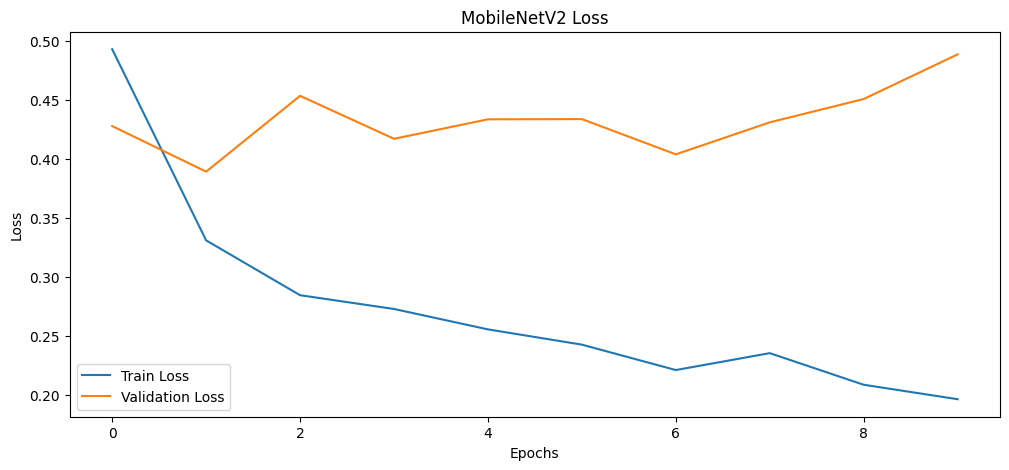

In [ ]:
#loss graph
plt.figure(figsize=(12,5))

plt.plot(mobilenet_history.history['loss'], label='Train Loss')
plt.plot(mobilenet_history.history['val_loss'], label='Validation Loss')

plt.title('MobileNetV2 Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')

plt.legend()
plt.show()

In [ ]:
import numpy as np
from sklearn.metrics import classification_report
class_names = list(train_generator.class_indices.keys())

print(class_names)

['Closed', 'Open', 'no_yawn', 'yawn']


In [ ]:
#model evaluation
Y_pred = mobilenet_model.predict(val_generator)

y_pred = np.argmax(Y_pred, axis=1)

print(classification_report(
    val_generator.classes,
    y_pred,
    target_names=class_names
))

19/19 ━━━━━━━━━━━━━━━━━━━━ 8s 405ms/step
              precision    recall  f1-score   support

      Closed       0.24      0.26      0.25       145
        Open       0.31      0.30      0.30       145
     no_yawn       0.28      0.20      0.23       145
        yawn       0.30      0.39      0.34       144

    accuracy                           0.28       579
   macro avg       0.28      0.29      0.28       579
weighted avg       0.28      0.28      0.28       579



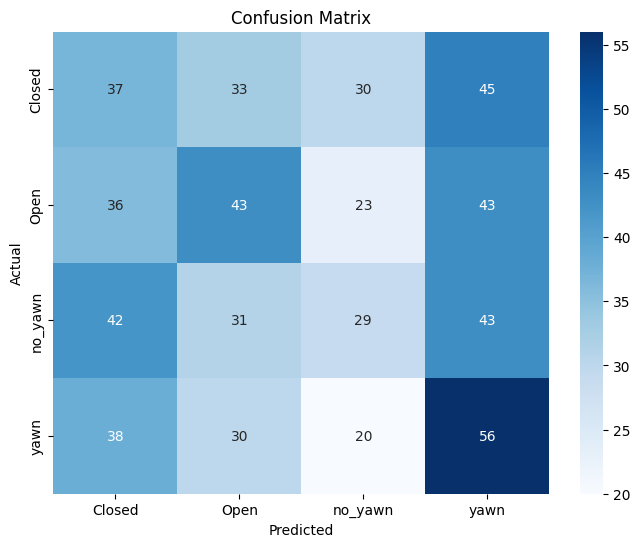

In [ ]:
#confusion matrix
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(val_generator.classes, y_pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.title('Confusion Matrix')

plt.show()

In [ ]:
#save model
mobilenet_model.save('driver_drowsiness_model.h5')

print("Model Saved")

Model Saved


In [ ]:
#signal image prediction
from tensorflow.keras.preprocessing import image

img_path = '/content/sample.jpg'

img = image.load_img(img_path, target_size=(224,224))

img_array = image.img_to_array(img)/255.0

img_array = np.expand_dims(img_array, axis=0)

prediction = mobilenet_model.predict(img_array)

predicted_class = class_names[np.argmax(prediction)]

print("Prediction:", predicted_class)

FileNotFoundError: [Errno 2] No such file or directory: '/content/sample.jpg'

In [ ]:
#3 level fatigue classification
def fatigue_level(prediction):

    if prediction in ['Open','no_yawn']:
        return 0, "Alert"

    elif prediction == 'yawn':
        return 1, "Mild Fatigue"

    elif prediction == 'Closed':
        return 2, "Severe Fatigue"

In [ ]:
#test fatigue level
# Example predicted class
predicted_class = "yawn"

# Fatigue Level Function
def fatigue_level(predicted_class):

    if predicted_class == "Open":
        return "Low", "Alert"

    elif predicted_class == "Closed":
        return "High", "Drowsy"

    elif predicted_class == "yawn":
        return "Medium", "Sleepy"

    elif predicted_class == "no_yawn":
        return "Low", "Normal"

# Get fatigue level
level, status = fatigue_level(predicted_class)

print("Fatigue Level:", level)
print("Driver Status:", status)

Fatigue Level: Medium
Driver Status: Sleepy


In [ ]:
#FATIGUE PROGRESSION CURVE
sample_predictions = [
    'Open','Open','no_yawn',
    'yawn','yawn',
    'Closed','Closed',
    'Open','yawn','Closed'
]

fatigue_scores = []

for pred in sample_predictions:

    level, _ = fatigue_level(pred)

    fatigue_scores.append(level)

print(fatigue_scores)

['Low', 'Low', 'Low', 'Medium', 'Medium', 'High', 'High', 'Low', 'Medium', 'High']


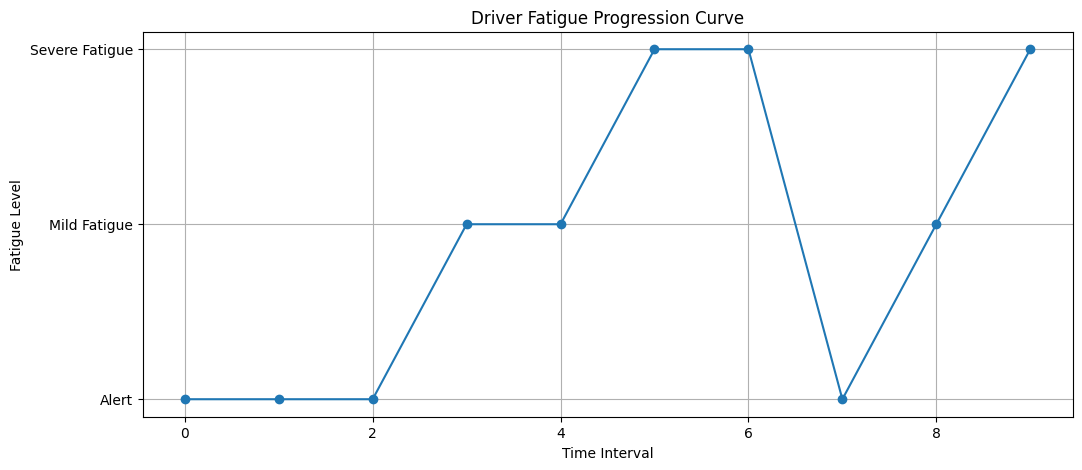

In [ ]:
#PLOT FATIGUE CURVE
time_intervals = np.arange(len(fatigue_scores))

plt.figure(figsize=(12,5))

plt.plot(
    time_intervals,
    fatigue_scores,
    marker='o'
)

plt.yticks(
    [0,1,2],
    ['Alert','Mild Fatigue','Severe Fatigue']
)

plt.xlabel("Time Interval")
plt.ylabel("Fatigue Level")

plt.title("Driver Fatigue Progression Curve")

plt.grid(True)

plt.show()

In [ ]:
from google.colab import files

files.download("driver_drowsiness_model.h5")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
#INTREPRETATION
for i, score in enumerate(fatigue_scores):

    if score == 1:
        print(f"Mild Fatigue started at interval {i}")

    elif score == 2:
        print(f"Severe Fatigue started at interval {i}")

In [ ]:
#TO LOAD MODEL AGAIN LATER
#from tensorflow.keras.models import load_model

#model = load_model("driver_drowsiness_model.h5")

In [ ]:
from tensorflow.keras.models import load_model

model = load_model("driver_drowsiness_model.h5")

print("Model Loaded Successfully")

Model Loaded Successfully
